In [1]:
import tensorflow as tf, keras
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

I0000 00:00:1790410620.381712      34 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.21.0 | Keras 3.13.2


## 1. Imports and Configuration

In [2]:
print("[Bloc 1] Imports et configuration : demarrage...")

import random, shutil, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v3 as iio          # required by the assignment (image loading/inspection)
import tensorflow as tf
import keras
from keras import layers
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score)

# Fixed seed: makes randomness (split, shuffle, weight init) reproducible,
# so different architectures can be compared fairly.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Project paths. Code runs inside the Docker container, where the repo is
# mounted at /workspace (see docker-compose.yml).
ROOT = Path("/workspace")
RAW = ROOT / "data_raw"      # raw images from TouNum, sorted into photo/ and autre/
DATA = ROOT / "data"         # created by split_dataset(): train/ val/ test/
RESULTS = ROOT / "results"   # trained models (.keras) + results CSV
LOGS = RESULTS / "logs"      # TensorBoard logs, one subfolder per architecture
RESULTS.mkdir(exist_ok=True)
LOGS.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)   # size expected by MobileNetV2 (transfer learning)
BATCH = 32

print("[Bloc 1] OK")

[Bloc 1] Imports et configuration : demarrage...
[Bloc 1] OK


## 2. Splitting the Dataset (train / val / test)

In [3]:
print("[Bloc 2] Splitting the dataset : demarrage...")

def split_dataset(ratios=(0.7, 0.15, 0.15), max_per_class=None, force=False):
    # force=True: wipe any previous split and redo it (e.g. switching from the
    # small test sample to the full dataset). data/ itself can be a symlink
    # (D: drive bind), so we clear its train/val/test children instead of
    # rmtree-ing data/ directly (Python refuses rmtree on a symlink).
    if force:
        for sub in ("train", "val", "test"):
            p = DATA / sub
            if p.exists():
                shutil.rmtree(p)
    if (DATA / "train").exists():
        print("data/train existe deja, decoupage ignore.")
        return
    print("Debut du decoupage...")
    ext = {".jpg", ".jpeg", ".png", ".bmp"}
    # Split each class separately, so train/val/test all stay balanced between photo and autre
    for cls in ["photo", "autre"]:
        print(f"Scan de {cls}/ ...")
        files = sorted(f for f in (RAW / cls).glob("*") if f.suffix.lower() in ext)
        print(f"  {len(files)} fichiers trouves dans {cls}/")
        random.Random(SEED).shuffle(files)   # reproducible shuffle before cutting
        if max_per_class is not None:
            files = files[:max_per_class]   # quick test run: keep only a random subset
        n = len(files)
        a, b = int(n * ratios[0]), int(n * (ratios[0] + ratios[1]))
        parts = {"train": files[:a], "val": files[a:b], "test": files[b:]}
        for split, fl in parts.items():
            dest = DATA / split / cls
            dest.mkdir(parents=True, exist_ok=True)
            print(f"  Copie de {cls}/{split} ({len(fl)} images)...")
            for i, f in enumerate(fl, start=1):
                shutil.copy(f, dest / f.name)   # copy, keep the originals in data_raw/ untouched
                if i % 500 == 0 or i == len(fl):
                    print(f"    {cls}/{split}: {i}/{len(fl)} images copiees")
        print(cls, {k: len(v) for k, v in parts.items()})

# Full dataset run: photo (9993) + autre (21406, schematics+text+sketch, paintings
# still excluded for now). force=True wipes the previous 300/class test split.
split_dataset(force=True)

print("[Bloc 2] OK")

[Bloc 2] Splitting the dataset : demarrage...
Debut du decoupage...
Scan de photo/ ...
  9993 fichiers trouves dans photo/
  Copie de photo/train (6995 images)...
    photo/train: 500/6995 images copiees
    photo/train: 1000/6995 images copiees
    photo/train: 1500/6995 images copiees
    photo/train: 2000/6995 images copiees
    photo/train: 2500/6995 images copiees
    photo/train: 3000/6995 images copiees
    photo/train: 3500/6995 images copiees
    photo/train: 4000/6995 images copiees
    photo/train: 4500/6995 images copiees
    photo/train: 5000/6995 images copiees
    photo/train: 5500/6995 images copiees
    photo/train: 6000/6995 images copiees
    photo/train: 6500/6995 images copiees
    photo/train: 6995/6995 images copiees
  Copie de photo/val (1499 images)...
    photo/val: 500/1499 images copiees
    photo/val: 1000/1499 images copiees
    photo/val: 1499/1499 images copiees
  Copie de photo/test (1499 images)...
    photo/test: 500/1499 images copiees
    photo/test

## 3. Loading the Images

In [4]:
print("[Bloc 3] Loading the images : demarrage...")

def load(split, shuffle):
    # Reads images directly from data/<split>/{photo,autre}/, labels inferred from folder names
    return keras.utils.image_dataset_from_directory(
        DATA / split, label_mode="binary", image_size=IMG_SIZE,
        batch_size=BATCH, shuffle=shuffle, seed=SEED)

# shuffle=True for train (re-shuffled every epoch), shuffle=False for val/test (stable order for evaluation)
train_ds, val_ds, test_ds = load("train", True), load("val", False), load("test", False)

class_names = train_ds.class_names
print(class_names)   # ['autre', 'photo'] -> autre = 0, photo = 1

# Prefetch: prepares the next batch on CPU while the GPU trains on the current one (speed only, no effect on results)
AUTOTUNE = tf.data.AUTOTUNE
train_ds, val_ds, test_ds = (d.prefetch(AUTOTUNE) for d in (train_ds, val_ds, test_ds))

print("[Bloc 3] OK")

[Bloc 3] Loading the images : demarrage...
Found 21979 files belonging to 2 classes.
Found 4710 files belonging to 2 classes.
Found 4710 files belonging to 2 classes.
['autre', 'photo']
[Bloc 3] OK


## 4. Visual Inspection of the Data

[Bloc 4] Visual inspection : demarrage...
[Bloc 4] OK


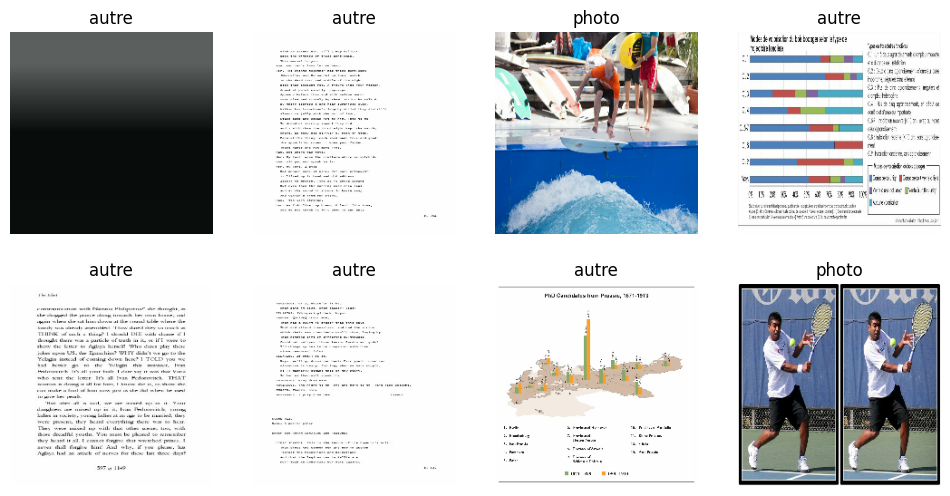

In [5]:
print("[Bloc 4] Visual inspection : demarrage...")

# Always look at the data before training: catches loading bugs, wrong labels,
# or corrupted images early.
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):   # grab a single batch from train_ds
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))   # cast back to displayable uint8 pixels
        plt.title(class_names[int(labels[i][0])])        # label -> human-readable class name
        plt.axis("off")

print("[Bloc 4] OK")

## 5. Data Augmentation (against overfitting)

In [6]:
print("[Bloc 5] Data augmentation : demarrage...")

# Small random transformations applied only during training. The model never sees
# the exact same image twice, which makes it harder to memorize the training set.
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),   # mirror left-right (a flipped photo is still a photo)
    layers.RandomRotation(0.1),        # random rotation up to 10% of a full turn (~36 degrees)
    layers.RandomZoom(0.1),            # random zoom in/out up to 10%
])

print("[Bloc 5] OK")

[Bloc 5] Data augmentation : demarrage...
[Bloc 5] OK


## 6. Building the Architectures to Compare

Three architectures, trained and evaluated the same way, to compare their bias/variance
trade-off: a CNN trained from scratch (baseline), pure transfer learning, and the
hybrid (transfer learning + our own CNN) — the one we keep as the final choice.

### 6.1 CNN from scratch (baseline)

In [ ]:
print("[Bloc 6.1] CNN from scratch : definition...")

def build_cnn_from_scratch(name="CNN_from_scratch"):
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = augment(inputs)                     # random flip/rotation/zoom, training only
    x = layers.Rescaling(1. / 255)(x)        # pixels 0-255 -> 0-1, this model learns from raw pixels
    x = layers.Conv2D(32, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)              # NEW: regularize after the first conv block
    x = layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)              # NEW: regularize after the second conv block
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)               # NEW: regularize before the final decision
    outputs = layers.Dense(1, activation="sigmoid")(x)   # single probability: photo (1) vs autre (0)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(loss="binary_crossentropy",
                  optimizer=keras.optimizers.Adam(1e-3),
                  metrics=["accuracy"])
    return model

print("[Bloc 6.1] OK")

[Bloc 6.1] CNN from scratch : definition...
[Bloc 6.1] OK


### 6.2 Pure transfer learning (MobileNetV2 + GlobalAveragePooling)

In [8]:
print("[Bloc 6.2] Pure transfer learning : definition...")

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def build_transfer_model(name="MobileNetV2_transfer"):
    base = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    base.trainable = False   # freeze: backprop never updates these weights

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = augment(inputs)
    x = preprocess_input(x)          # MobileNetV2's own scaling, not Rescaling(1/255)
    x = base(x, training=False)      # frozen feature extractor -> 7x7x1280 feature grid
    x = layers.GlobalAveragePooling2D()(x)   # average each of the 1280 feature maps into 1 number
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(loss="binary_crossentropy",
                  optimizer=keras.optimizers.Adam(1e-3),
                  metrics=["accuracy"])
    return model

print("[Bloc 6.2] OK")

[Bloc 6.2] Pure transfer learning : definition...
[Bloc 6.2] OK


### 6.3 Hybrid — MobileNetV2 (frozen) + our own CNN — final architecture

In [9]:
print("[Bloc 6.3] Hybrid model : definition...")

def build_hybrid_model(name="Hybrid_MobileNetV2"):
    base = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    base.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = augment(inputs)
    x = preprocess_input(x)
    x = base(x, training=False)       # frozen feature extractor -> 7x7x1280 feature grid
    # Our own hand-built CNN on top of the frozen features (1-2 blocks max: the grid is already small)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(loss="binary_crossentropy",
                  optimizer=keras.optimizers.Adam(1e-3),
                  metrics=["accuracy"])
    return model

print("[Bloc 6.3] OK")

[Bloc 6.3] Hybrid model : definition...
[Bloc 6.3] OK


## 7. Training (with Callbacks)

In [10]:
print("[Bloc 7] Training function : definition...")

def train(model, epochs=100):
    callbacks = [
        # Stop early if val_loss stops improving for 3 epochs in a row, and roll back
        # to the weights from the best epoch (not the last one)
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        # Save the model to disk, but only overwrite the file when val_loss improves
        keras.callbacks.ModelCheckpoint(str(RESULTS / f"{model.name}.keras"), save_best_only=True),
        # Write per-epoch metrics for this model to its own log subfolder, for TensorBoard
        keras.callbacks.TensorBoard(log_dir=str(LOGS / model.name)),
    ]
    history = model.fit(train_ds, validation_data=val_ds,
                         epochs=epochs, callbacks=callbacks)
    return model, history

print("[Bloc 7] OK")

[Bloc 7] Training function : definition...
[Bloc 7] OK


In [11]:
print("[Bloc 7b] Lancement de l'entrainement des 3 modeles...")

# Build and train the 3 architectures one by one, keep the model + its history for later
builders = [build_cnn_from_scratch, build_transfer_model, build_hybrid_model]

models, histories = {}, {}
for build_fn in builders:
    model = build_fn()
    print(f"\n=== Training: {model.name} ===\n")
    model, history = train(model)
    models[model.name] = model
    histories[model.name] = history

print("\nEND")
print("[Bloc 7b] OK")

[Bloc 7b] Lancement de l'entrainement des 3 modeles...

=== Training: CNN_from_scratch ===

Epoch 1/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 421s 611ms/step - accuracy: 0.9268 - loss: 0.2074 - val_accuracy: 0.9529 - val_loss: 0.1219
Epoch 2/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 416s 606ms/step - accuracy: 0.9558 - loss: 0.1189 - val_accuracy: 0.9541 - val_loss: 0.1178
Epoch 3/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 419s 610ms/step - accuracy: 0.9643 - loss: 0.0978 - val_accuracy: 0.9654 - val_loss: 0.0955
Epoch 4/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 427s 621ms/step - accuracy: 0.9672 - loss: 0.0912 - val_accuracy: 0.9654 - val_loss: 0.1054
Epoch 5/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 421s 612ms/step - accuracy: 0.9683 - loss: 0.0888 - val_accuracy: 0.9684 - val_loss: 0.0915
Epoch 6/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 1369s 2s/step - accuracy: 0.9728 - loss: 0.0797 - val_accuracy: 0.9677 - val_loss: 0.0970
Epoch 7/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 441s 641ms/step - accuracy: 0.9757 - loss: 0.0726 - val_accuracy: 0.972

## 8. Loss / Accuracy Curves (Train vs Validation)

[Bloc 8] Loss / accuracy curves : demarrage...


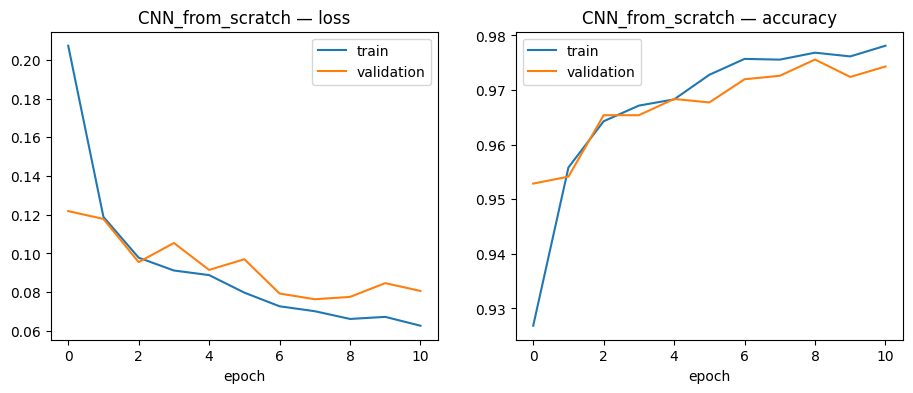

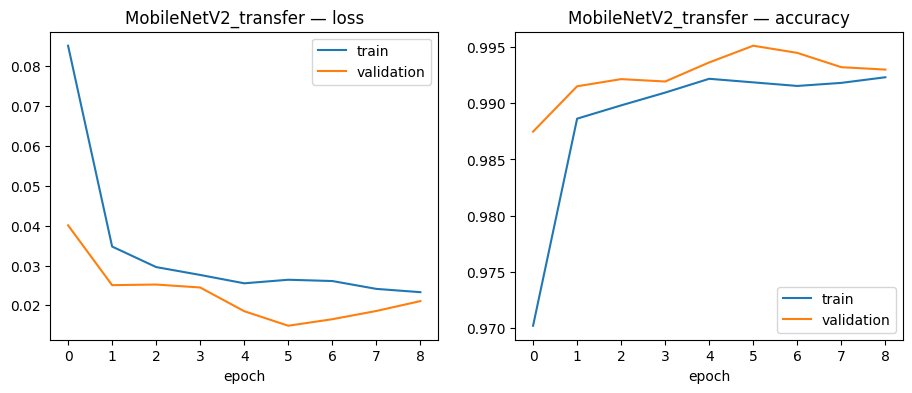

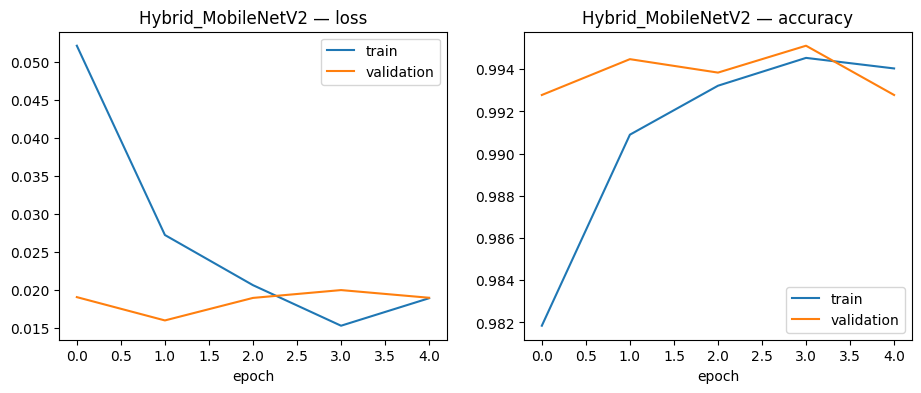

[Bloc 8] OK


In [12]:
print("[Bloc 8] Loss / accuracy curves : demarrage...")

def plot_history(h, title=""):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for a, m in zip(ax, ["loss", "accuracy"]):
        a.plot(h.history[m], label="train")
        a.plot(h.history["val_" + m], label="validation")   # h.history stores one list per metric, per epoch
        a.set_title(f"{title} — {m}")
        a.set_xlabel("epoch")
        a.legend()
    plt.show()

# One pair of curves (loss, accuracy) per architecture, required by the assignment
for name, history in histories.items():
    plot_history(history, title=name)

print("[Bloc 8] OK")

## 9. Final Evaluation on the Test Set

In [13]:
print("[Bloc 9] Final evaluation : demarrage...")

import io

def fig_to_tf_image(fig):
    # Convert a matplotlib figure into a TensorBoard-loggable image tensor
    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    plt.close(fig)                    # don't display inline, only send it to TensorBoard
    buf.seek(0)
    img = tf.image.decode_png(buf.getvalue(), channels=4)
    return tf.expand_dims(img, 0)     # tf.summary.image expects a batch dimension

def evaluate_and_log(name, model):
    print(f"  Evaluation de {name}...")
    # True labels for the whole test set, in the same fixed order (shuffle=False)
    y_true = np.concatenate([y.numpy() for _, y in test_ds]).ravel().astype(int)

    t0 = time.time()
    y_prob = model.predict(test_ds, verbose=0).ravel()   # sigmoid probabilities
    ms_per_img = (time.time() - t0) / len(y_true) * 1000  # inference speed, useful for TouNum in prod
    y_pred = (y_prob > 0.5).astype(int)                    # threshold 0.5 -> 0/1 class

    report = classification_report(y_true, y_pred, target_names=class_names)

    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                            display_labels=class_names).plot(ax=ax)
    ax.set_title(name)

    # Send the confusion matrix + report to this model's TensorBoard run instead
    # of showing them inline in the notebook
    eval_writer = tf.summary.create_file_writer(str(LOGS / name / "eval"))
    with eval_writer.as_default():
        tf.summary.image("Confusion Matrix", fig_to_tf_image(fig), step=0)
        tf.summary.text("Classification Report", report, step=0)

    row = {
        "modele": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_photo": precision_score(y_true, y_pred),
        "recall_photo": recall_score(y_true, y_pred),
        "f1_photo": f1_score(y_true, y_pred),
        "ms_par_image": round(ms_per_img, 2),
        "parametres": model.count_params(),
        "taille_Mo": round((RESULTS / f"{name}.keras").stat().st_size / 1e6, 1),
    }
    # Append this model's row to the comparison CSV, replacing any previous row for the same model
    path = RESULTS / "livrable1_resultats.csv"
    df = pd.read_csv(path) if path.exists() else pd.DataFrame()
    df = pd.concat([df[df.get("modele") != name] if len(df) else df,
                    pd.DataFrame([row])], ignore_index=True)
    df.to_csv(path, index=False)
    print(f"  {name}: OK")
    return df

for name, model in models.items():
    results_df = evaluate_and_log(name, model)

print("[Bloc 9] OK")
results_df

[Bloc 9] Final evaluation : demarrage...
  Evaluation de CNN_from_scratch...
  CNN_from_scratch: OK
  Evaluation de MobileNetV2_transfer...
  MobileNetV2_transfer: OK
  Evaluation de Hybrid_MobileNetV2...
  Hybrid_MobileNetV2: OK
[Bloc 9] OK


,modele,accuracy,precision_photo,recall_photo,f1_photo,ms_par_image,parametres,taille_Mo
0,CNN_from_scratch,0.974522,0.952131,0.968646,0.960317,3.87,11963457,143.6
1,MobileNetV2_transfer,0.994480,0.985498,0.997332,0.991379,12.89,2259265,9.6
2,Hybrid_MobileNetV2,0.994692,0.988079,0.995330,0.991692,13.02,3013825,18.7


## 10. Bias/Variance Analysis

**Dataset complet** : 21 979 images train / 4 710 val / 4 710 test (photo + schematics/text/sketch, peintures exclues pour l'instant).

### CNN_from_scratch (baseline)
- Accuracy train 92.7% → 97.8% sur 11 epochs (arrêt par `EarlyStopping`), val 95.3% → 97.4%.
- Loss train finit à 0.063, loss val à 0.081 : écart modéré mais stable, pas de divergence qui s'aggrave.
- Léger surapprentissage, bien contenu grâce au volume de données (22k images) et à la data augmentation.
- **Accuracy test finale : 97.45%**

### MobileNetV2_transfer (transfer learning pur)
- Accuracy train 97.0% → 99.2%, val 98.75% → 99.3% (meilleur epoch : 6, val_loss = 0.0149).
- Courbes train/val quasiment confondues du début à la fin → overfitting quasi nul, comportement attendu (backbone gelé = très peu de paramètres réellement appris).
- **Accuracy test finale : 99.45%**

### Hybrid_MobileNetV2 (architecture retenue)
- Convergence très rapide : val_accuracy déjà à 99.28% dès l'epoch 1.
- Meilleur val_loss à l'epoch 2 (0.016), puis légère remontée (0.019-0.020) → `EarlyStopping` arrête à l'epoch 5 et restaure les poids de l'epoch 2 (`restore_best_weights=True`).
- Léger surapprentissage détecté, mais neutralisé immédiatement par le callback.
- **Accuracy test finale : 99.47%** (meilleur score des 3 modèles)

### Comparaison avec l'essai sur échantillon réduit (300 images/classe)
Sur le petit échantillon de test, ce même modèle hybride montrait un surapprentissage net et **progressif** (val_loss passant de 0.070 à 0.183 sur 5 epochs, accuracy val en baisse après l'epoch 3). Sur le dataset complet, le même modèle converge tout aussi vite mais avec un surapprentissage **beaucoup plus contenu** (val_loss 0.016 → 0.019 seulement). Ça confirme empiriquement, avec des chiffres à l'appui, ce qui est attendu en théorie : à architecture égale, plus de données réduit directement le surapprentissage.

### Conclusion
Aucun signe de sous-apprentissage sur les 3 modèles (tous >97% d'accuracy en train et en val). Le compromis biais/variance est bien maîtrisé grâce à la combinaison volume de données + data augmentation + EarlyStopping. Le modèle **hybride** reste le choix recommandé : meilleure accuracy test, overfitting contenu, et architecture explicable couche par couche (contrairement au transfer learning pur, boîte noire côté MobileNetV2).